In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("../data/raw/walmart.xlsx")

In [3]:
df_clean = df.copy()

In [4]:
df_clean.shape

(3203, 12)

In [5]:
df_clean.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64

In [6]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_percentage.sort_values(ascending=False)

Order ID         0.0
Order Date       0.0
Ship Date        0.0
Customer Name    0.0
Country          0.0
City             0.0
State            0.0
Category         0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Profit           0.0
dtype: float64

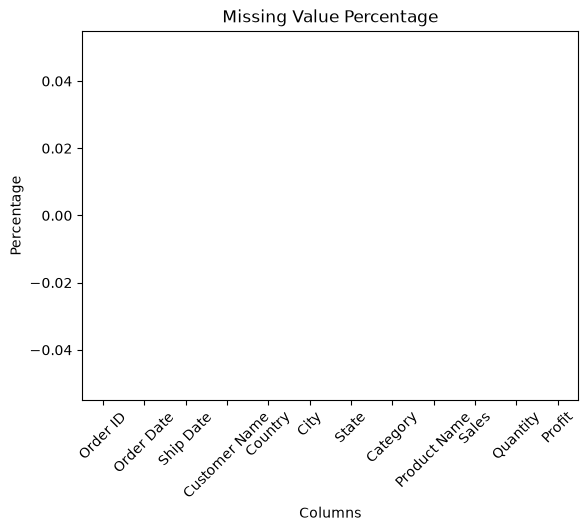

In [7]:
import matplotlib.pyplot as plt

missing_percentage.plot(kind='bar')

plt.title("Missing Value Percentage")
plt.xlabel("Columns")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

In [8]:
df_clean.duplicated().sum()

np.int64(0)

In [9]:
df_clean = df_clean.drop_duplicates()

In [10]:
df_clean.dtypes

Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Customer Name               str
Country                     str
City                        str
State                       str
Category                    str
Product Name                str
Sales                   float64
Quantity                  int64
Profit                  float64
dtype: object

In [11]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])

In [12]:
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   str           
 1   Order Date     3203 non-null   datetime64[us]
 2   Ship Date      3203 non-null   datetime64[us]
 3   Customer Name  3203 non-null   str           
 4   Country        3203 non-null   str           
 5   City           3203 non-null   str           
 6   State          3203 non-null   str           
 7   Category       3203 non-null   str           
 8   Product Name   3203 non-null   str           
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   int64         
 11  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(7)
memory usage: 300.4 KB


In [14]:
df_clean.describe()

,Order Date,Ship Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440,2013-05-14 01:25:25.195129,226.493233,3.828910,33.849032
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800
std,NaN,NaN,524.876877,2.260947,174.109081


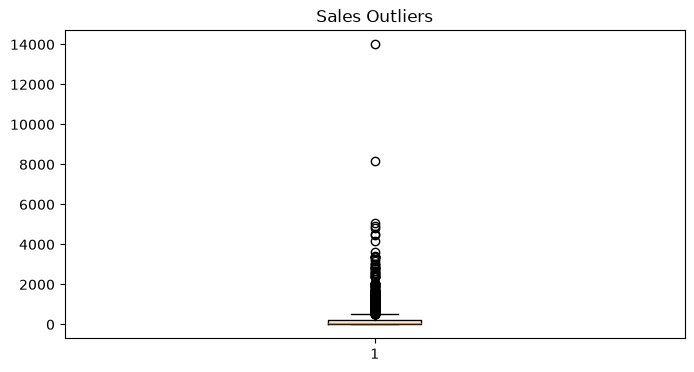

In [15]:
plt.figure(figsize=(8,4))

plt.boxplot(df_clean["Sales"])

plt.title("Sales Outliers")

plt.show()

In [16]:
Q1 = df_clean["Sales"].quantile(0.25)
Q3 = df_clean["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -275.1135
Upper Bound: 510.36249999999995


In [17]:
outliers = df_clean[
    (df_clean["Sales"] < lower_bound) |
    (df_clean["Sales"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 368


In [18]:
outliers.sort_values(by="Sales", ascending=False).head(20)

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
2663,CA-2014-140151,2014-03-24,2014-03-26,Raymond Buch,United States,Seattle,Washington,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,6719.9808
799,CA-2011-143917,2011-07-25,2011-07-27,Ken Lonsdale,United States,San Francisco,California,Supplies,High Speed Automatic Electric Letter Opener,8187.650,5,327.5060
2846,CA-2014-135909,2014-10-14,2014-10-21,Jane Waco,United States,Sacramento,California,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,5083.960,5,1906.4850
1913,CA-2013-136301,2013-03-14,2013-03-16,Edward Hooks,United States,San Francisco,California,Supplies,High Speed Automatic Electric Letter Opener,4912.590,3,196.5036
1319,CA-2014-149881,2014-04-02,2014-04-04,Nick Crebassa,United States,San Francisco,California,Machines,Cubify CubeX 3D Printer Double Head Print,4799.984,2,359.9988
2533,CA-2013-138478,2013-10-22,2013-10-27,Dennis Pardue,United States,North Las Vegas,Nevada,Binders,Ibico EPK-21 Electric Binding System,4535.976,3,1644.2913
2927,CA-2013-100300,2013-06-25,2013-06-27,Max Jones,United States,San Diego,California,Machines,Okidata MB760 Printer,4476.800,4,503.6400
1973,CA-2013-159016,2013-03-11,2013-03-12,Karen Ferguson,United States,Los Angeles,California,Phones,Apple iPhone 5,4158.912,8,363.9048
376,CA-2011-168494,2011-12-12,2011-12-14,Nora Preis,United States,Fresno,California,Tables,Bretford Rectangular Conference Table Tops,3610.848,12,135.4068
3084,CA-2013-107104,2013-11-27,2013-12-01,Maribeth Schnelling,United States,Los Angeles,California,Bookcases,DMI Eclipse Executive Suite Bookcases,3406.664,8,160.3136


In [19]:
print(df_clean.shape)

(3203, 12)


In [20]:
print(df_clean.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Customer Name', 'Country',
       'City', 'State', 'Category', 'Product Name', 'Sales', 'Quantity',
       'Profit'],
      dtype='str')


In [21]:
outliers.sort_values(by="Sales", ascending=False).head(10)

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
2663,CA-2014-140151,2014-03-24,2014-03-26,Raymond Buch,United States,Seattle,Washington,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,6719.9808
799,CA-2011-143917,2011-07-25,2011-07-27,Ken Lonsdale,United States,San Francisco,California,Supplies,High Speed Automatic Electric Letter Opener,8187.650,5,327.5060
2846,CA-2014-135909,2014-10-14,2014-10-21,Jane Waco,United States,Sacramento,California,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,5083.960,5,1906.4850
1913,CA-2013-136301,2013-03-14,2013-03-16,Edward Hooks,United States,San Francisco,California,Supplies,High Speed Automatic Electric Letter Opener,4912.590,3,196.5036
1319,CA-2014-149881,2014-04-02,2014-04-04,Nick Crebassa,United States,San Francisco,California,Machines,Cubify CubeX 3D Printer Double Head Print,4799.984,2,359.9988
2533,CA-2013-138478,2013-10-22,2013-10-27,Dennis Pardue,United States,North Las Vegas,Nevada,Binders,Ibico EPK-21 Electric Binding System,4535.976,3,1644.2913
2927,CA-2013-100300,2013-06-25,2013-06-27,Max Jones,United States,San Diego,California,Machines,Okidata MB760 Printer,4476.800,4,503.6400
1973,CA-2013-159016,2013-03-11,2013-03-12,Karen Ferguson,United States,Los Angeles,California,Phones,Apple iPhone 5,4158.912,8,363.9048
376,CA-2011-168494,2011-12-12,2011-12-14,Nora Preis,United States,Fresno,California,Tables,Bretford Rectangular Conference Table Tops,3610.848,12,135.4068
3084,CA-2013-107104,2013-11-27,2013-12-01,Maribeth Schnelling,United States,Los Angeles,California,Bookcases,DMI Eclipse Executive Suite Bookcases,3406.664,8,160.3136


In [22]:
df_clean.to_excel("../data/processed/walmart_clean.xlsx", index=False)